In [ ]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "1,2"

from transformers import AutoTokenizer
from vllm import LLM, SamplingParams

model_name = "Qwen/Qwen3-4B"
tokenizer = AutoTokenizer.from_pretrained(model_name)
llm = LLM(model=model_name, dtype="auto", tensor_parallel_size=2)

In [ ]:
from datasets import load_dataset, concatenate_datasets


LCB_SYSTEM_MESSAGE_GENERIC = "You are an expert Python programmer. You will be given a question (problem specification) and will generate a correct Python program that matches the specification and passes all tests."
LCB_SYSTEM_MESSAGE_SPARTAN = """
You are an **Expert Python Programmer** and **Spartan Code Generator**. Your **SOLE GOAL** is to generate a **100% Correct Python Program or Function** that strictly adheres to the Spartan Programming paradigm.

**MANDATORY SPARTAN CONSTRAINTS:**
1.  **Correctness First:** Code must be correct and pass all tests.
2.  **Minimize Volume:** Minimize LoC, tokens, and characters. Avoid all comments/docstrings/empty lines. Use compact K&R formatting.
3.  **Minimize State:** Minimize variables. Inline single-use variables. Use single-character/short names (e.g., 'n', 'i', 'x'). Define variables at the smallest scope.
4.  **Simplify Flow:** Minimize explicit `if`/`elif`/`else`. Aggressively use **ternaries** and lookups. Minimize nesting. Prefer built-ins (`sum`, `map`) and **comprehensions** over explicit loops. Employ **early `return`** to flatten logic.
5.  **Concise Routines:** Keep routines extremely short. Minimize parameters.

**FEW-SHOT EXAMPLES:**
def sq(n): return n*n if n > 0 else 0
def se(l): return sum(x for x in l if x % 2 == 0)
def f(n): return 1 if n <= 1 else n * f(n-1)
def uc(l): return list(map(lambda s: s.upper(), l))
"""

eval_file_paths = [f"/private/schwartz-lab/yarin_shaked7/SkyRL/test_shards/test_livecodebench_part_000{i}.json" for i in range(1,7)]
eval_datasets = [load_dataset("json", data_files=path, split="train") for path in eval_file_paths]
eval_dataset = concatenate_datasets(eval_datasets)
eval_df = eval_dataset.to_pandas()

eval_df["formatted_prompt"] = eval_df["prompt"].apply(lambda x: tokenizer.apply_chat_template(x, tokenize=False, add_generation_prompt=True))
#eval_df["formatted_prompt"] = eval_df["formatted_prompt"].apply(lambda x: x.replace(LCB_SYSTEM_MESSAGE_SPARTAN, LCB_SYSTEM_MESSAGE_GENERIC))
eval_prompts = eval_df["formatted_prompt"].tolist()
eval_df.head()

In [ ]:
sampling_params = SamplingParams(
    repetition_penalty=1.0,
    temperature=0,
    top_p=1,
    top_k=-1,
    min_p=0.0,
    max_tokens=4000,
)

outputs = llm.generate(eval_prompts, sampling_params)
responses = [output.outputs[0].text for output in outputs]
eval_df["response"] = responses

import pickle
with open("spartan_baseline_evaluation.pkl", "wb") as f:
    pickle.dump(eval_df, f)


In [ ]:
from skyrl_gym.envs.lcb.livecodebench import compute_score
from tqdm import tqdm
import pickle

with open("baseline_evaluation.pkl", "rb") as f:
    eval_df = pickle.load(f)

for idx, (reponse, tests) in tqdm(enumerate(zip(eval_df["response"], eval_df["reward_spec"])), desc="Evaluating responses"):
    tests = eval(tests["ground_truth"])
    parsed_code, reward = compute_score(reponse, tests)
    eval_df.loc[idx, "parsed_code"] = parsed_code
    eval_df.loc[idx, "reward"] = reward
    idx += 1


eval_df.reward.value_counts()

In [ ]:
with open("baseline_evaluation.pkl", "rb") as f:
    eval_df = pickle.load(f)

with open("spartan_baseline_evaluation.pkl", "rb") as f:
    spartan_eval_df = pickle.load(f)


In [8]:
from skyrl_gym.envs.lcb.livecodebench import extract_code_from_model

eval_df["code"] = eval_df["response"].apply(extract_code_from_model)
spartan_eval_df["code"] = spartan_eval_df["response"].apply(extract_code_from_model)

# Filter to only the indices where BOTH dataframes have non-None code
valid_idxs = eval_df["code"].notna() & spartan_eval_df["code"].notna()
eval_df = eval_df[valid_idxs].reset_index(drop=True)
spartan_eval_df = spartan_eval_df[valid_idxs].reset_index(drop=True)


Error: Invalid Python syntax.


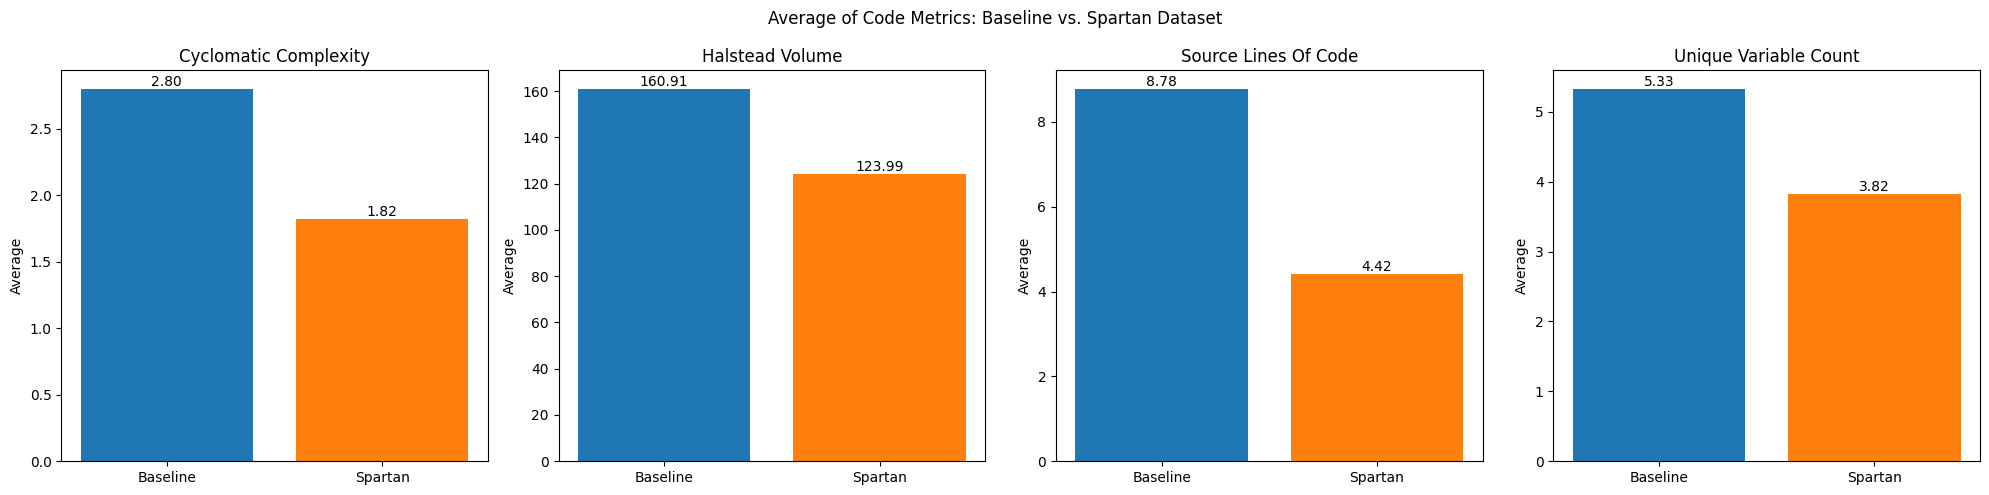

In [11]:
from general_utils import calculate_cyclomatic_complexity, calculate_halstead_volume, calculate_source_lines_of_code, calculate_unique_variable_count
import matplotlib.pyplot as plt
import numpy as np

# Calculate metrics for both dataframes
eval_df["cyclomatic_complexity"] = eval_df["code"].apply(calculate_cyclomatic_complexity)
eval_df["halstead_volume"] = eval_df["code"].apply(calculate_halstead_volume)
eval_df["source_lines_of_code"] = eval_df["code"].apply(calculate_source_lines_of_code)
eval_df["unique_variable_count"] = eval_df["code"].apply(calculate_unique_variable_count)

spartan_eval_df["cyclomatic_complexity"] = spartan_eval_df["code"].apply(calculate_cyclomatic_complexity)
spartan_eval_df["halstead_volume"] = spartan_eval_df["code"].apply(calculate_halstead_volume)
spartan_eval_df["source_lines_of_code"] = spartan_eval_df["code"].apply(calculate_source_lines_of_code)
spartan_eval_df["unique_variable_count"] = spartan_eval_df["code"].apply(calculate_unique_variable_count)

# Define the metrics to plot
metrics = [
    ("cyclomatic_complexity", "Cyclomatic Complexity"),
    ("halstead_volume", "Halstead Volume"),
    ("source_lines_of_code", "Source Lines Of Code"),
    ("unique_variable_count", "Unique Variable Count")
]

# Plot comparison of means for each metric
fig, axs = plt.subplots(1, 4, figsize=(20, 5))

for i, (metric, metric_name) in enumerate(metrics):
    avg_eval = eval_df[metric].mean()
    avg_spartan = spartan_eval_df[metric].mean()
    axs[i].bar(
        ["Baseline", "Spartan"],
        [avg_eval, avg_spartan],
        color=["tab:blue", "tab:orange"]
    )
    axs[i].set_ylabel("Average")
    axs[i].set_title(metric_name)
    axs[i].set_xticks([0, 1])
    axs[i].set_xticklabels(["Baseline", "Spartan"])
    # Show average on top of the bars
    for j, val in enumerate([avg_eval, avg_spartan]):
        axs[i].text(j, val, f"{val:.2f}", ha='center', va='bottom')

plt.suptitle("Average of Code Metrics: Baseline vs. Spartan Dataset")
plt.tight_layout()
plt.show()